**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Estudiante:** Huaman Guizgueta Fernando Jesus  
---

## Tarea:
Utilizar weka para limpiar o corregir los datos erroneos del dataset "diabetes" y mostrar el arbol(J48) corregido.

# Clasificación de Diabetes con Weka

## Dataset
Se utilizó el dataset Pima Diabetes.

Contenido:
- 768 registros.
- 9 atributos
- 1 variable de clase

## Limpieza
Se identificaron valores 0 inconsistentes en las variables:
- plas(5 ceros)
- pres(35 ceros)
- skin(227 ceros)
- insu(374 ceros)
- mass(11 ceros)

Estos valores fueron tratados como datos faltantes(?) y posteriormente
se utilizó ReplaceMissingValues de Weka para darles un valor respecto a la media.
## Modelo
Se utilizó el J48 para construir un árbol de decisión.

Para el arbol primero considere de esta forma los atributos:
- preg: Numero de embarazos
- plas: Concentración de glucosa en plasma
- pres: presión arterial.
- skin: Grosor de pliegue cutáneo
- insu: Nivel de insulina
- mass: Índice de masa corporal
- pedi: Función de antecedentes familiares de diabetes
- age: edad
- Class: Variable de clase. El resultado, diabetes/ no diabetes

Y con eso encontre valores inconsistentes dados, ya que en plas, pres, skin, insu, mass y age. no pueden tomar valores de "0".


## Weka antes de la modificación:

Aqui se ven valores de 0 en Minimum y eso es erroneo ya que no puedes tener una concentración de glucosa en plasma de 0 y requiere un cambio en ese dato pero weka no entiende eso y sigue un proceso normal en el desarrollo.

![Captura de pantalla 2026-09-25 200457.png](<attachment:Captura de pantalla 2026-09-25 200457.png>)
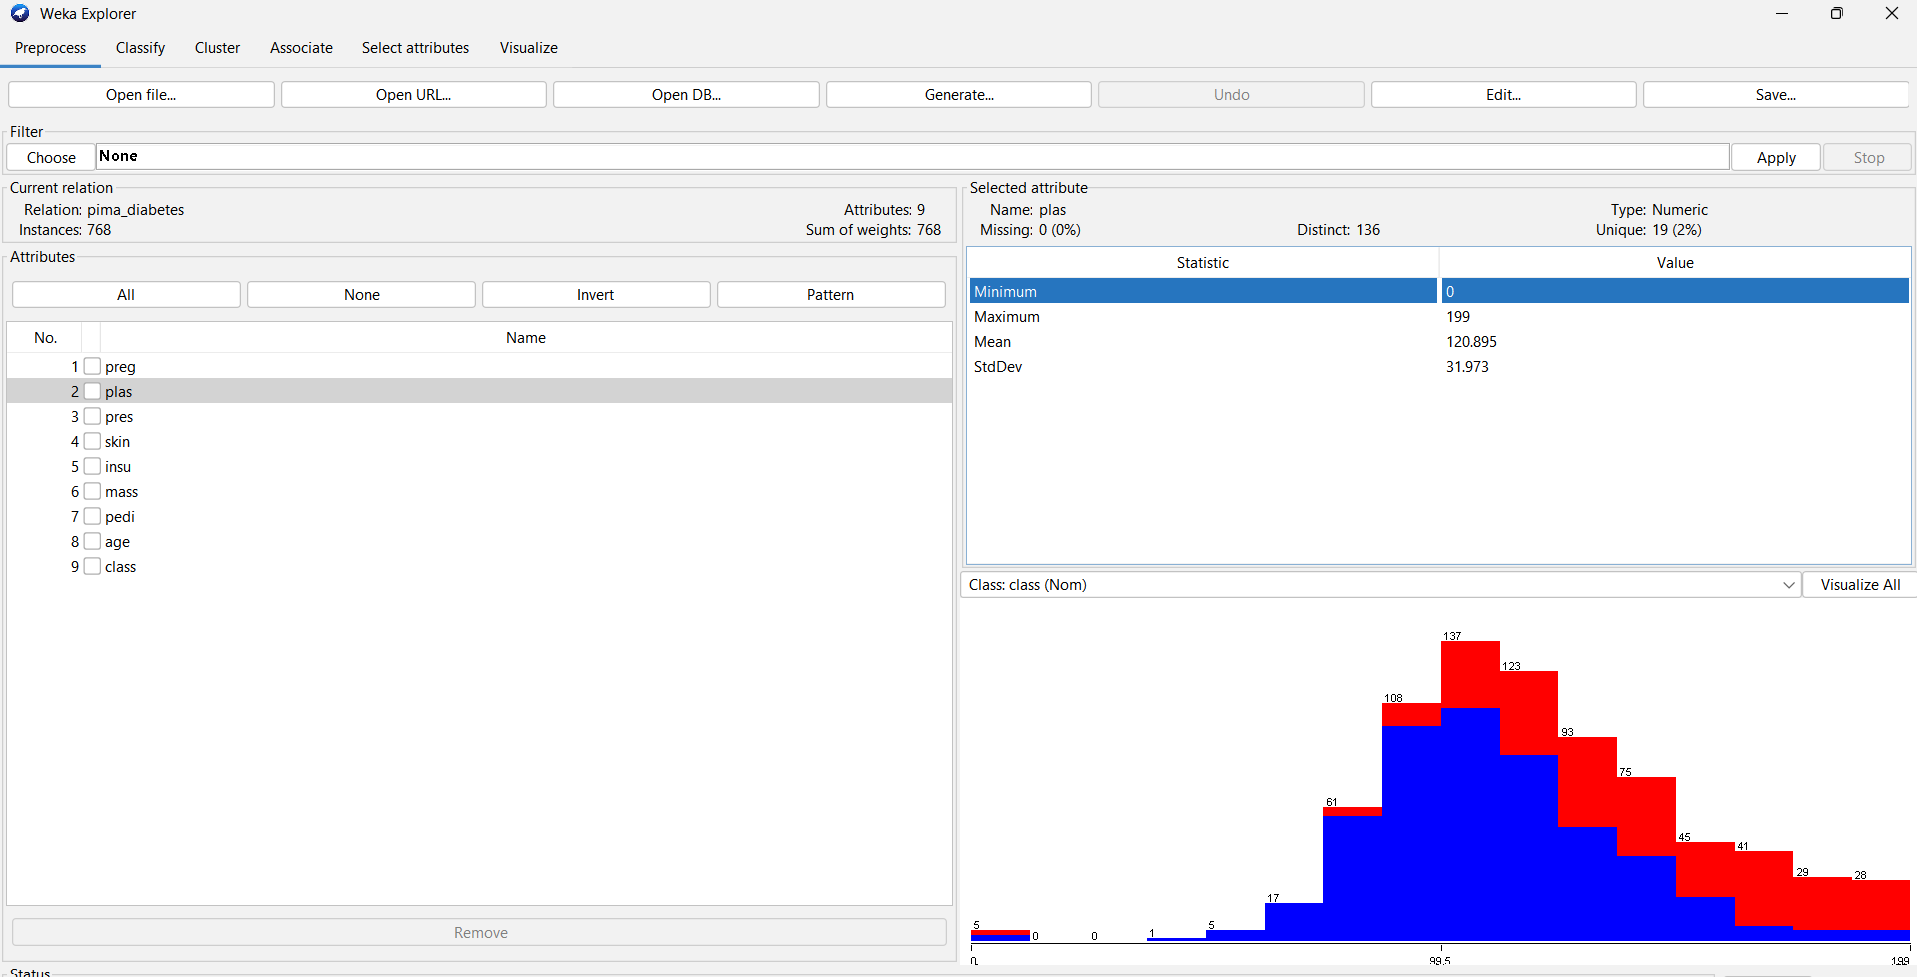

## Arbol antes, considerando los ceros 

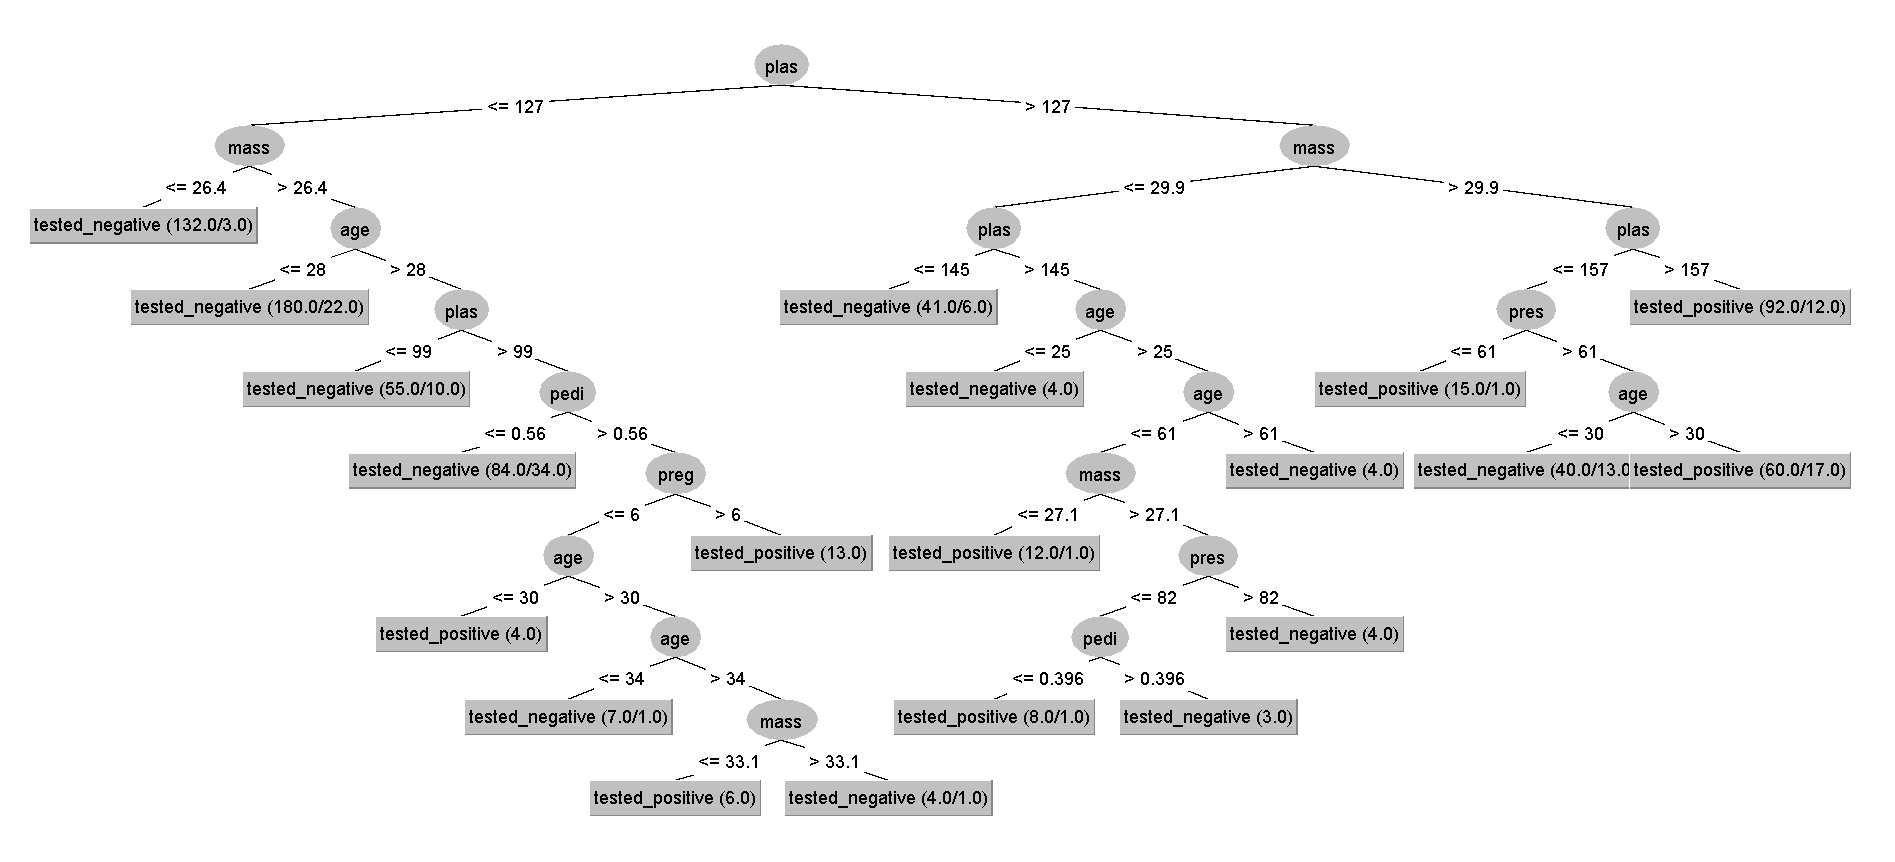

## Weka cambiado:

para eso primero nos vamos a edit...  y cambiamos los valores de 0 por ?, y tras eso quedarian un espacio en blanco.

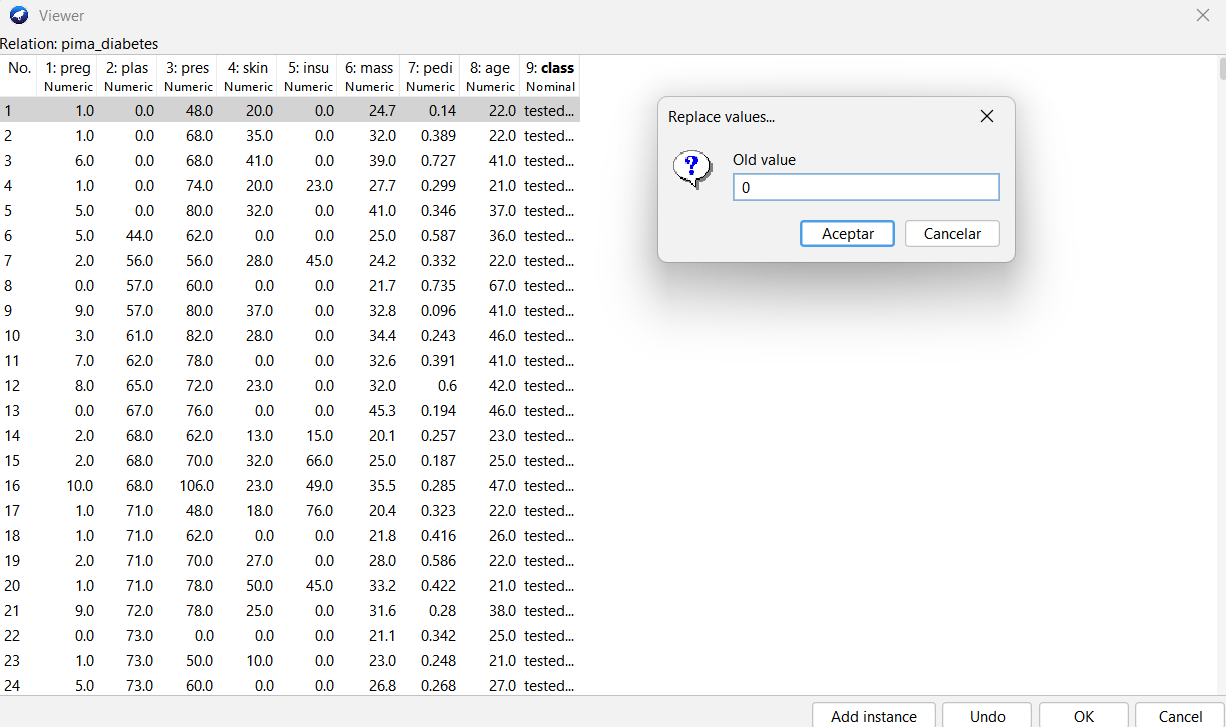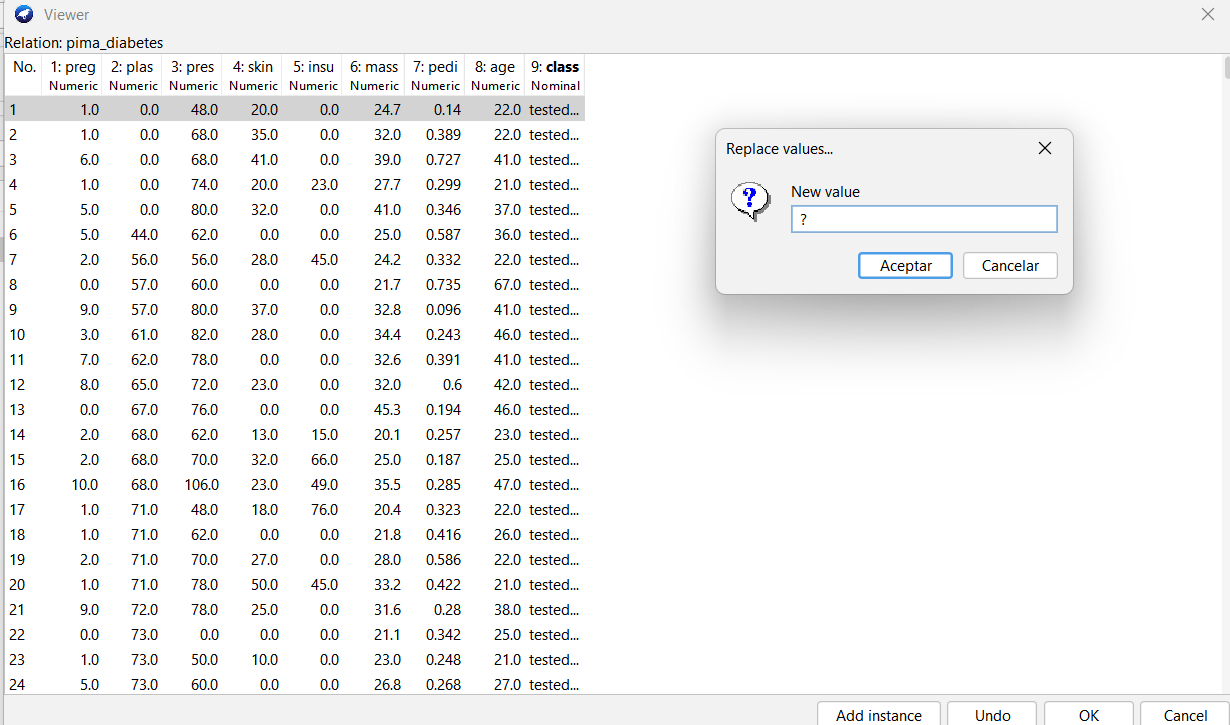


## Arbol despues de la limpieza(cambiando los ceros inconsistentes):

En este cambio si modifique los valores invalidos de una parte de los atributos(plas, pres,skin,insu y mass), primero reemplazando los valores "0" a "?" para que weka los considere como valores faltantes y asi usando el filtro "ReplaceMissingValues"(choose->filters->unsupervised->attribute->ReplaceMissingValues) que permitió reemplazar los valores faltantes por valores calculados a partir de los datos disponibles. Por esta razón, algunos valores resultantes presentan varios decimales.

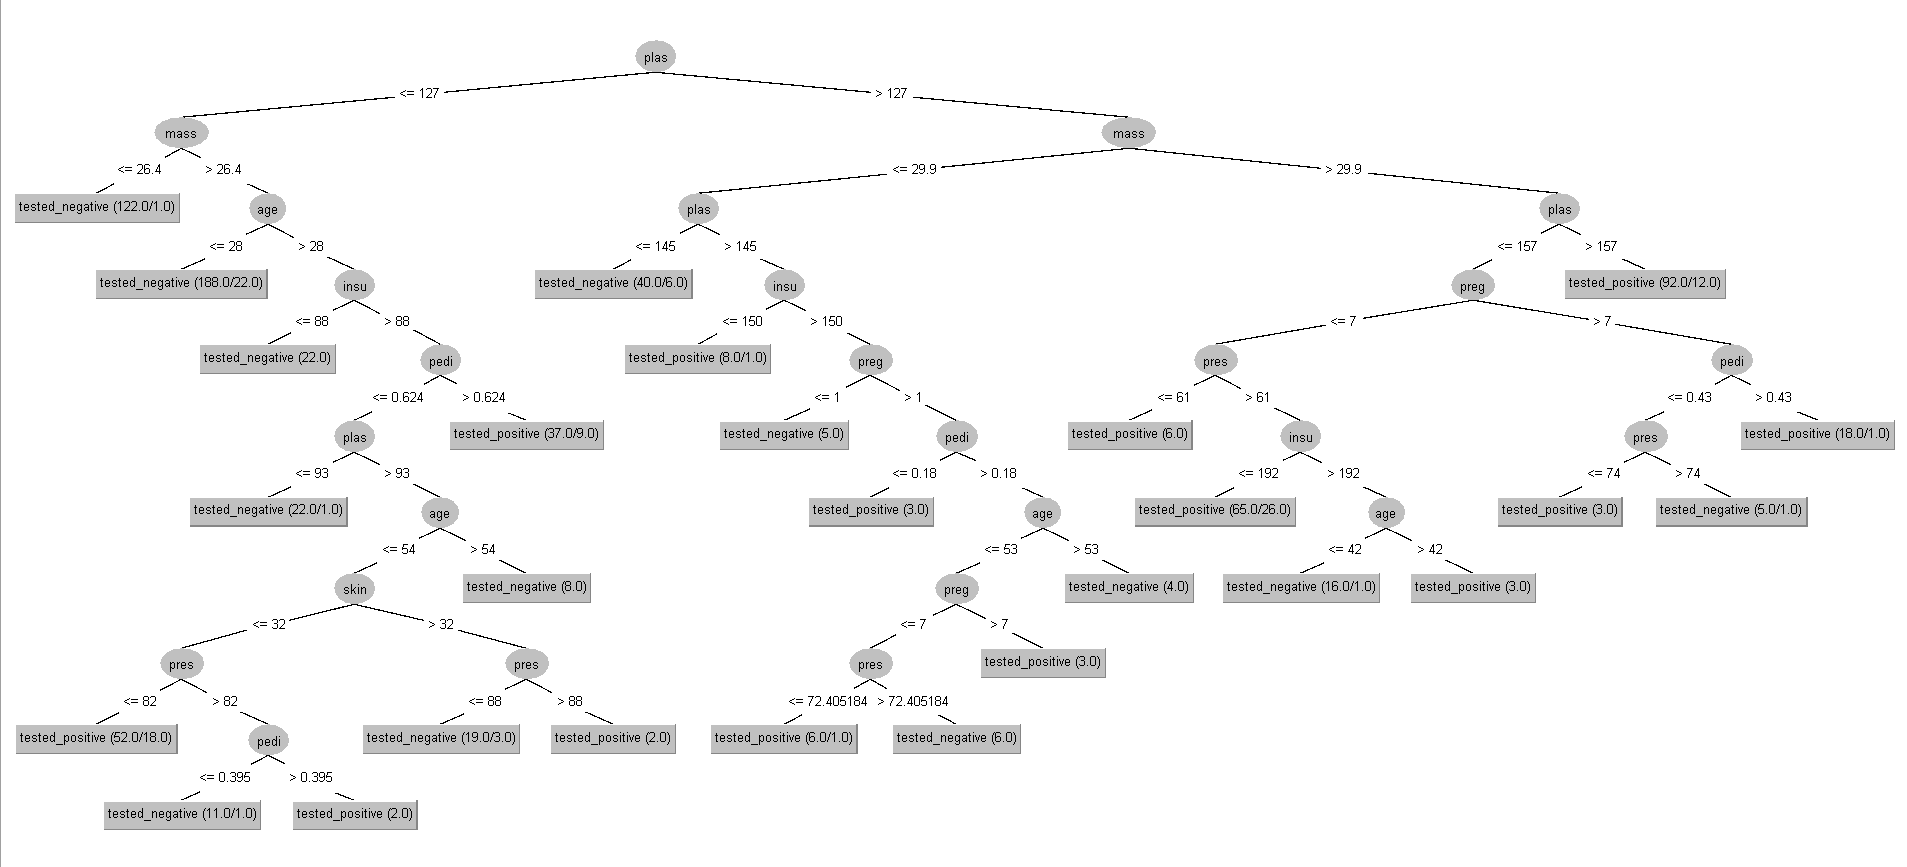


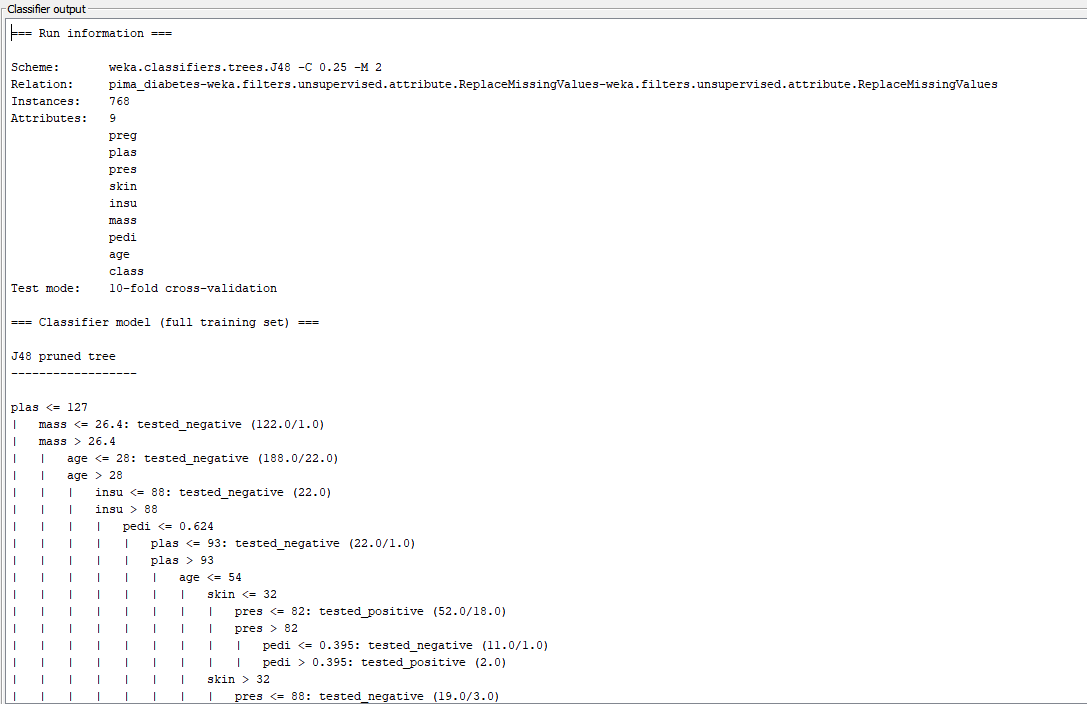
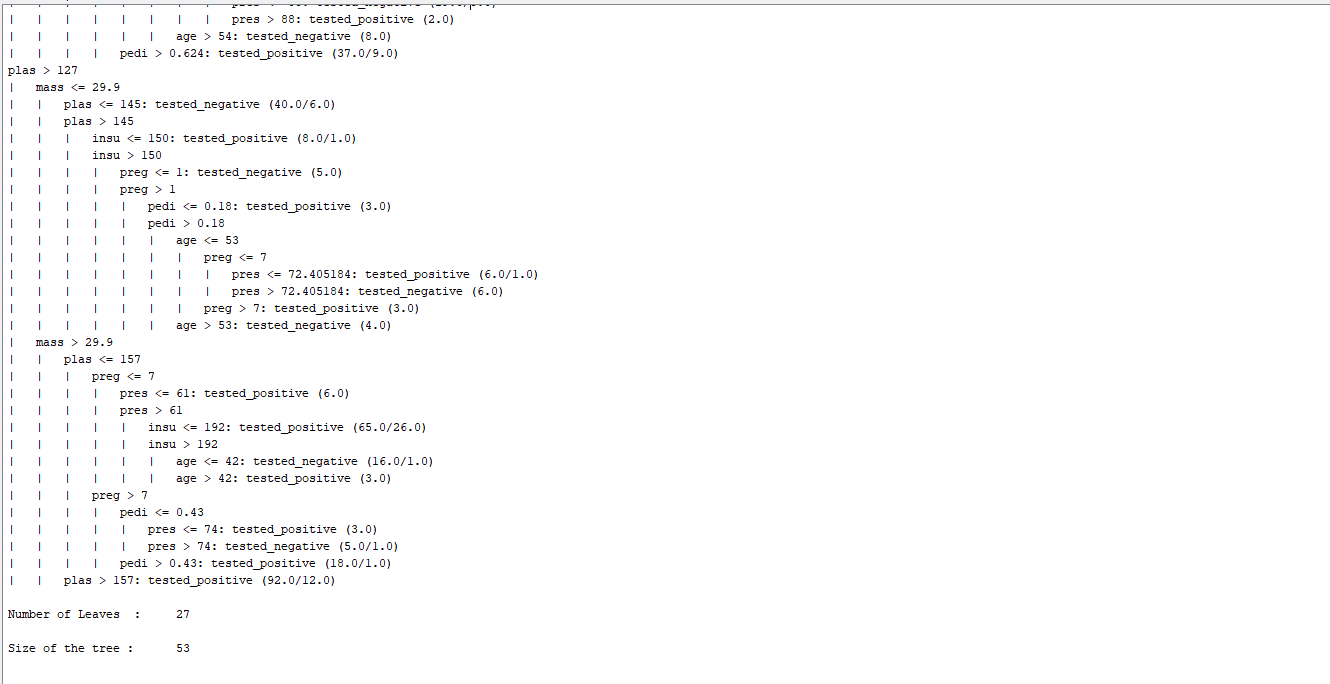
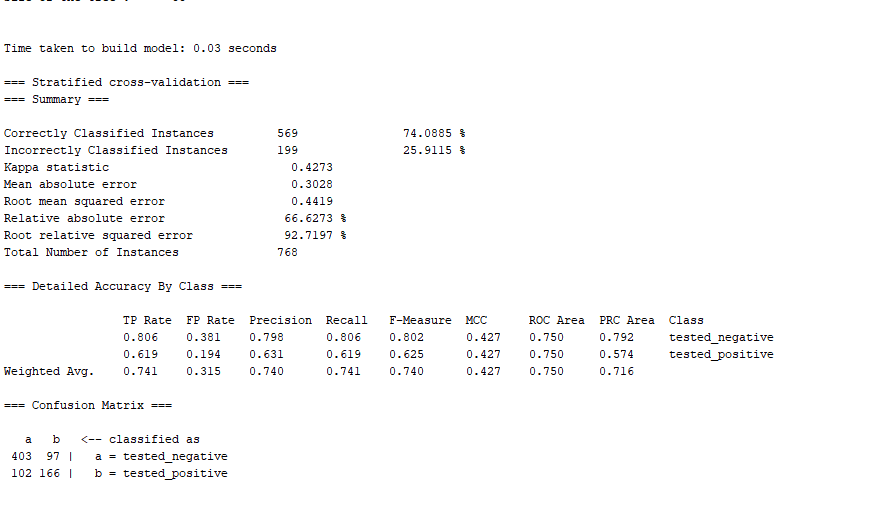

## Conclusión:

Comparando ambos árboles de decición(J48) logré sacar las siguientes conclusiones:

1. La raíz del árbol no cambia (plas ≤ 127)
El primer corte sigue siendo plas con el mismo umbral (127) en ambas versiones. Esto tiene sentido porque plas solo tenía 5 ceros inconsistentes, un número tan pequeño que casi no afecta la media ni la capacidad discriminativa de ese atributo.

2. Los atributos con más ceros (insu y skin) eran por asi decirlo, obviados para el árbol antes de la limpieza
Antes de corregir los datos, insu (374 ceros) y skin (227 ceros) casi no aparecen como nodos de decisión en el árbol original, porque un valor 0 repetido en cientos de registros no le sirve al arbol de decición para separar clases. Por eso el árbol de antes resuelve la clasificación apoyándose repetidamente en plas, mass, age, pedi y preg.

Después de aplicar ReplaceMissingValues, insu y skin recuperan variabilidad real entre registros y sí aparecen como nodos de decisión

3. El árbol después de la limpieza:
Al activarse los nuevos atributos útiles (insu, skin), J48 encuentra más combinaciones para separar los datos, generando más niveles y más hojas que el árbol original. Es decir, la limpieza no solo cambia qué variables se usan, sino que aumenta la complejidad del modelo porque ahora hay más información real disponible para dividir los datos.